<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week5/wine_DL_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# 회귀 분류: 와인의 Alcohol를 예측하는 모델

In [33]:
import pandas as pd
import numpy as np;

file_path = '/content/drive/MyDrive/Colab Notebooks/wine.csv'

df = pd.read_csv(file_path);
df.head()


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [34]:
# 정답(label) 데이터 설정
# 알코올 도수
y = df['Alcohol']
print(y.value_counts());

Alcohol
13.05    6
12.37    6
12.08    5
12.29    4
12.00    3
        ..
12.82    1
12.20    1
14.16    1
13.27    1
14.13    1
Name: count, Length: 126, dtype: int64


In [35]:
Y = y.values

In [36]:
# 입력 데이터(feature) 생성
X=df.drop('Alcohol',axis=1)
X.head()

,Wine,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [37]:
# 딥러닝 입력을 위해 Numpy로 변환
X = X.values

In [38]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# 모델 구성
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # input_shape 에 숫자로 칼럼 개수 지정 가능
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1) # 연속 값 예측이므로 활성화 함수가 없다
])

# 컴파일, 학습
model.compile(
    optimizer="adam",
    loss="mae", # 손실함수
    metrics=["mae"] #평가지표
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 12.6617 - mae: 12.6617 - val_loss: 12.0980 - val_mae: 12.0980
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.9904 - mae: 11.9904 - val_loss: 11.4548 - val_mae: 11.4548
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.2654 - mae: 11.2654 - val_loss: 10.7705 - val_mae: 10.7705
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 10.6483 - mae: 10.6483 - val_loss: 10.0165 - val_mae: 10.0165
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.7525 - mae: 9.7525 - val_loss: 9.1402 - val_mae: 9.1402
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.7991 - mae: 8.7991 - val_loss: 8.0813 - val_mae: 8.0813
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.5638 - mae: 7.5638 - val_loss: 6.8492 - val_mae: 6.8492
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.9073 - mae: 5.9073 - val_loss: 5.4246 - val_mae: 5.4246
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.9186 - mae: 4.91

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


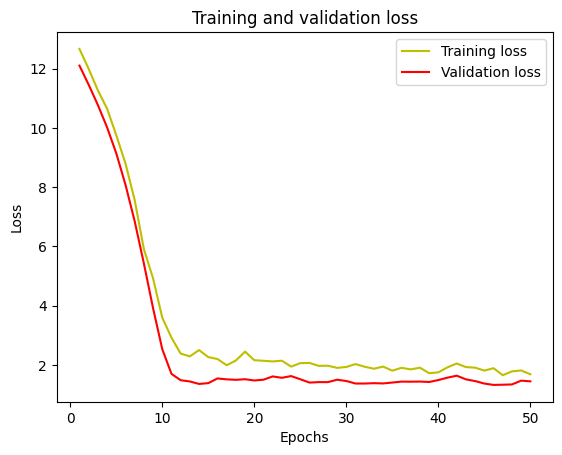

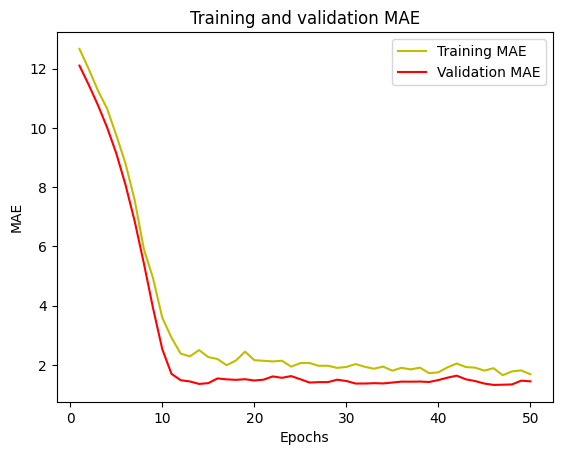

MAE : 1.5290984524620903
MSE : 3.360619445456767
RMSE: 1.833199237796254


In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(loss) + 1)

# loss 그래프
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MAE 그래프
plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# 회귀 평가지표
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)